In [10]:
import sys
from palivla.components.sequence_builder import SequenceBuilder
from palivla.components.cot_sequence_builder import CoTSequenceBuilder
from palivla.components.action_tokenizer import FASTActionTokenizer

sys.path.insert(0,'/nfs/nfs2/users/riadoshi/bigvision_palivla/')
sys.path.insert(0, '/nfs/nfs2/users/riadoshi/bigvision_palivla/src/')
sys.path.insert(0,'/nfs/nfs2/users/riadoshi/bigvision_palivla/dlimp')
sys.path.insert(0,'/nfs/nfs2/users/riadoshi/bigvision_palivla/models')


from octo.data.oxe import make_oxe_dataset_kwargs
from octo.data.dataset import make_single_dataset


from transformers import AutoTokenizer

import mediapy 
import matplotlib.pyplot as plt 
import numpy as np

In [ ]:
# load tokenizers
# load action and language tokenizers
padded_sequence_builder = CoTSequenceBuilder(prompt_pad_length=50, gen_pad_length=150, action_chunk_pad_length=50)
og_sequence_builder = CoTSequenceBuilder(prompt_pad_length=50, gen_pad_length=150, action_chunk_pad_length=4)

language_tokenizer = AutoTokenizer.from_pretrained("google/paligemma2-3b-pt-224")
action_tokenizer = FASTActionTokenizer(min_action_value=-3, max_action_value=3)

In [2]:
# load datasets
bridge_dataset_kwargs = make_oxe_dataset_kwargs('bridge_dataset',"gs://rail-orca-central2/resize_256_256/")

# env vars
OG_CHUNK_SIZE, OG_ACTION_DIM = 4, 7
PADDED_CHUNK_SIZE, PADDED_ACTION_DIM = 50, 14

# padded dataset
padded_dataset = make_single_dataset(
    bridge_dataset_kwargs, 
    frame_transform_kwargs=dict(
        resize_size={"primary": (224, 224)},
    ),
    traj_transform_kwargs=dict(
        action_horizon=PADDED_CHUNK_SIZE,
        max_action_dim=PADDED_ACTION_DIM,
    ),
    train=True
)

# original dataset
orig_dataset = make_single_dataset(
    bridge_dataset_kwargs, 
    frame_transform_kwargs=dict(
        resize_size={"primary": (224, 224)},
    ),
    traj_transform_kwargs=dict(
        action_horizon=OG_CHUNK_SIZE,
        max_action_dim=OG_ACTION_DIM,
    ),
    train=True
)

padded_iterator = padded_dataset.iterator()
orig_iterator = orig_dataset.iterator()

2025-04-11 23:11:57.847548: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


AttributeError: module 'ml_dtypes' has no attribute 'float4_e2m1fn'
Cause: Unable to locate the source code of <function _gcd_import at 0x7f283b037d80>. Note that functions defined in certain environments, like the interactive Python shell, do not expose their source code. If that is the case, you should define them in a .py source file. If you are certain the code is graph-compatible, wrap the call using @tf.autograph.experimental.do_not_convert. Original error: could not get source code
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: Unable to locate the source code of <function _gcd_import at 0x7f283b037d80>. Note that functions defined in certain environments, like the interactive Python shell, do not expose their source code. If that is the case, you should define them in a .py source file. If you are certain the code is graph-compatible, wrap the call using @tf.autograph.experimental.do_not_convert. Original error: could not get source code
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: Unable to locate the source code of <function _gcd_import at 0x7f283b037d80>. Note that functions defined in certain environments, like the interactive Python shell, do not expose their source code. If that is the case, you should define them in a .py source file. If you are certain the code is graph-compatible, wrap the call using @tf.autograph.experimental.do_not_convert. Original error: could not get source code
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


In [3]:
# get fifty samples each from each dataset: 
pactions, oactions = [], []
for _ in range(50):
    ptraj = next(padded_iterator)
    otraj = next(orig_iterator)

    assert ptraj['action'].shape[0] == otraj['action'].shape[0]
    traj_len = ptraj['action'].shape[0]

    rand_idx = np.random.randint(0, traj_len)
    pactions.append(ptraj['action'][rand_idx])
    oactions.append(otraj['action'][rand_idx])


In [25]:
# tokenize & detokenize
detokenized_pacs, detokenized_oacs = [], []
for pac in pactions:
    pac = pac.squeeze()
    tokenized_pac = action_tokenizer.tokenize(pac, action_chunk_size=OG_CHUNK_SIZE) # we use the original bc we do per-dataset chunking
    detokenized_pac = action_tokenizer.detokenize(
        np.array(tokenized_pac), 
        action_chunk_size=OG_CHUNK_SIZE,  # we use the original bc we do per-dataset chunking
        action_dim=PADDED_ACTION_DIM
    )
    detokenized_pacs.append(detokenized_pac)

for oac in oactions:
    oac = oac.squeeze()
    tokenized_oac = action_tokenizer.tokenize(oac, action_chunk_size=OG_CHUNK_SIZE)
    detokenized_oac = action_tokenizer.detokenize(
        np.array(tokenized_oac), 
        action_chunk_size=OG_CHUNK_SIZE, 
        action_dim=OG_ACTION_DIM
    )
    detokenized_oacs.append(detokenized_oac)

detokenized_oacs, detokenized_pacs = np.array(detokenized_oacs), np.array(detokenized_pacs)


In [28]:
# we want to discard the last seven dimensions of the 14D action for pacs 
# and we also want to 
detokenized_pacs_0 = detokenized_pacs[:, 0, :7].squeeze()
detokenized_oacs_0 = detokenized_oacs[:, 0, :].squeeze()

In [31]:
detokenized_pacs_0.shape
detokenized_oacs_0.shape

(50, 7)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]


[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]


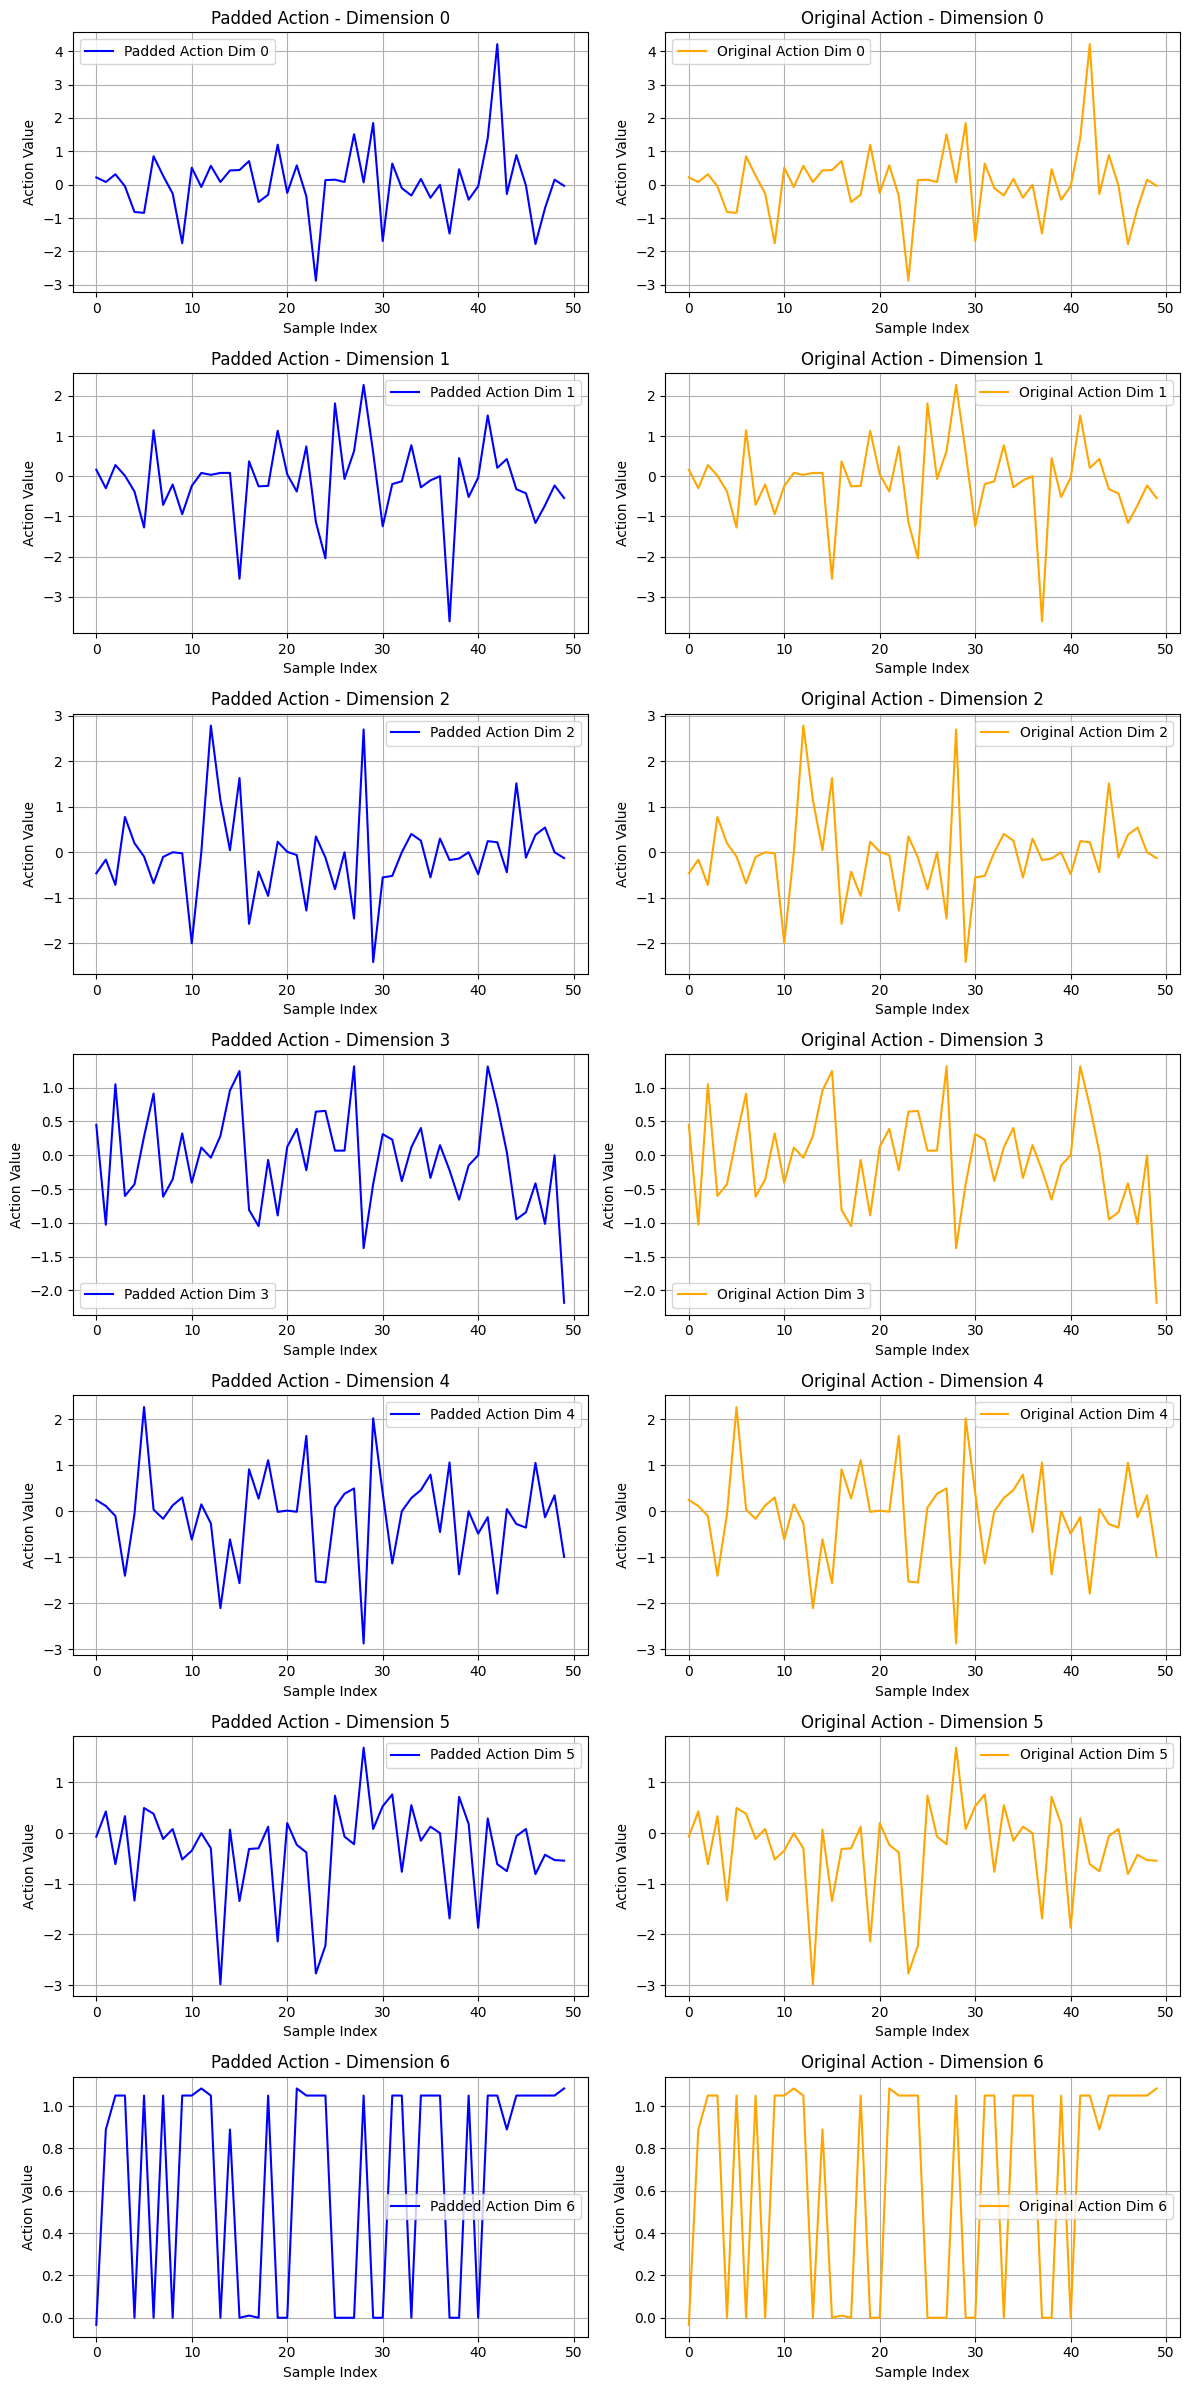

In [43]:
# Plot line graphs for each dimension of detokenized_pacs and detokenized_oacs separately
import matplotlib.pyplot as plt
import numpy as np

# Number of dimensions to plot
num_dims = 7

# Create a figure with subplots for each dimension (2 plots per dimension)
fig, axes = plt.subplots(num_dims, 2, figsize=(12, 24))

# For each dimension i, plot detokenized_pacs[:, i] and detokenized_oacs[:, i] in separate plots
for i in range(num_dims):
    # Plot padded actions
    assert detokenized_pacs.shape[-1] == 14
    # print(detokenized_pacs[:, 1, 10])
    axes[i, 0].plot(range(len(detokenized_pacs)), detokenized_pacs[:, 1, i], label=f'Padded Action Dim {i}', color='blue')
    axes[i, 0].set_title(f'Padded Action - Dimension {i}')
    axes[i, 0].set_xlabel('Sample Index')
    axes[i, 0].set_ylabel('Action Value')
    axes[i, 0].legend()
    axes[i, 0].grid(True)
    
    # Plot original actions
    assert detokenized_oacs.shape[-1] == 7
    axes[i, 1].plot(range(len(detokenized_oacs)), detokenized_oacs[:, 1, i], label=f'Original Action Dim {i}', color='orange')
    axes[i, 1].set_title(f'Original Action - Dimension {i}')
    axes[i, 1].set_xlabel('Sample Index')
    axes[i, 1].set_ylabel('Action Value')
    axes[i, 1].legend()
    axes[i, 1].grid(True)

plt.tight_layout()
plt.show()
